In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Configurações visuais globais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carregar os dados (vamos usar o dataset já limpo)
df = pd.read_csv('Dataset/earthquakes_cleaned.csv')

# 1. Ajustar o alvo: Tratar os 'Unknown' como ausência de alerta
df['alert'] = df['alert'].replace('Unknown', 'No_Alert')

# 2. Criar uma coluna numérica ordinal para o alerta (para correlações)
mapeamento_alertas = {
    'No_Alert': 0,
    'green': 1,
    'yellow': 2,
    'orange': 3,
    'red': 4
}
df['alert_encoded'] = df['alert'].map(mapeamento_alertas)

print("Dados carregados e alvo configurado!")
df[['alert', 'alert_encoded']].value_counts().sort_index()

Dados carregados e alvo configurado!


alert     alert_encoded
No_Alert  0                222
green     1                353
orange    3                  3
red       4                  4
yellow    2                 20
Name: count, dtype: int64

C:\Users\julio\AppData\Local\Temp\ipykernel_22200\2592127464.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='alert', order=['No_Alert', 'green', 'yellow', 'orange', 'red'],


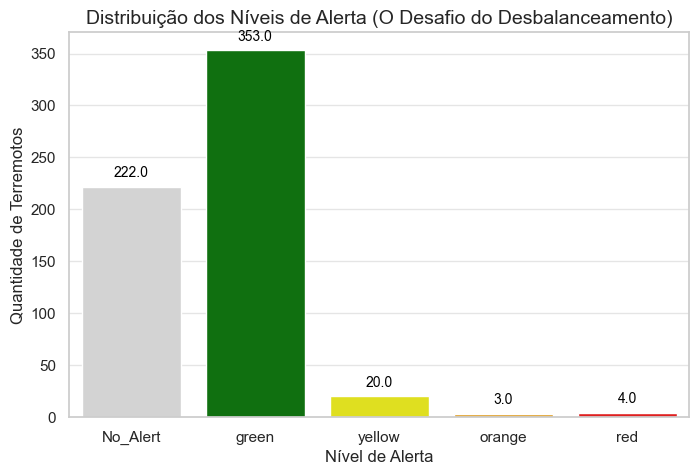

In [7]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='alert', order=['No_Alert', 'green', 'yellow', 'orange', 'red'],
                   palette=['lightgray', 'green', 'yellow', 'orange', 'red'])

plt.title('Distribuição dos Níveis de Alerta (O Desafio do Desbalanceamento)', fontsize=14)
plt.ylabel('Quantidade de Terremotos')
plt.xlabel('Nível de Alerta')

# Adicionar os valores exatos em cima das barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

C:\Users\julio\AppData\Local\Temp\ipykernel_22200\4054086584.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='alert', y=col, order=['No_Alert', 'green', 'yellow', 'orange', 'red'],
C:\Users\julio\AppData\Local\Temp\ipykernel_22200\4054086584.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='alert', y=col, order=['No_Alert', 'green', 'yellow', 'orange', 'red'],
C:\Users\julio\AppData\Local\Temp\ipykernel_22200\4054086584.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='alert', y=col, order=['No_A

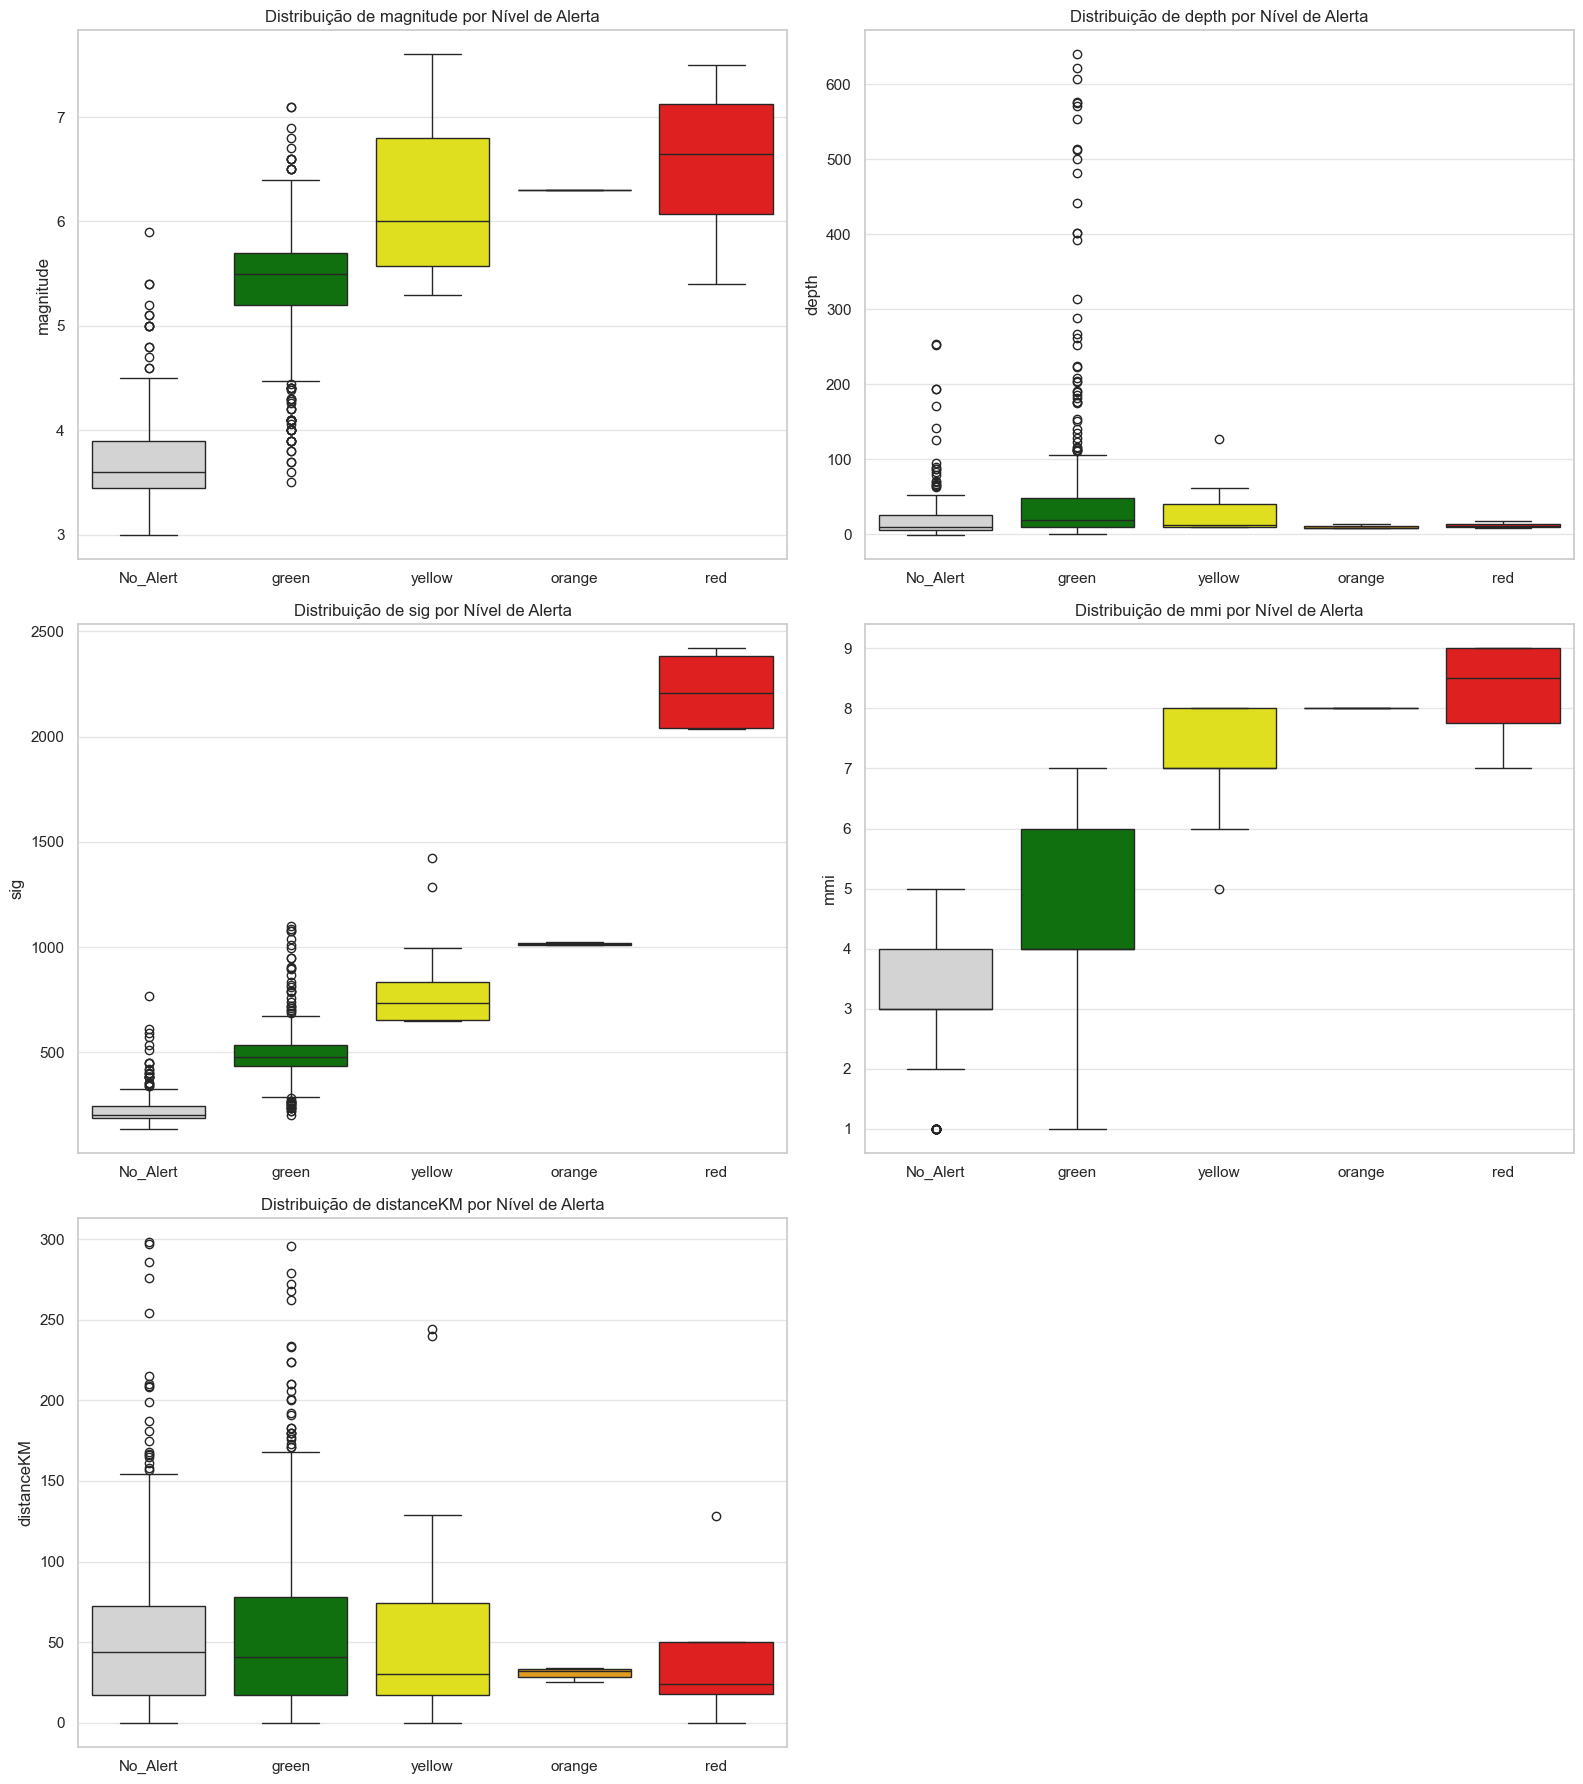

In [8]:
# Escolhendo as numéricas mais promissoras
features_numericas = ['magnitude', 'depth', 'sig', 'mmi', 'distanceKM']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

ordem_cores = ['lightgray', 'green', 'yellow', 'orange', 'red']

for i, col in enumerate(features_numericas):
    sns.boxplot(data=df, x='alert', y=col, order=['No_Alert', 'green', 'yellow', 'orange', 'red'],
                palette=ordem_cores, ax=axes[i])
    axes[i].set_title(f'Distribuição de {col} por Nível de Alerta', fontsize=12)
    axes[i].set_xlabel('')

# Remover o último gráfico vazio (já que temos 5 variáveis e 6 espaços)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

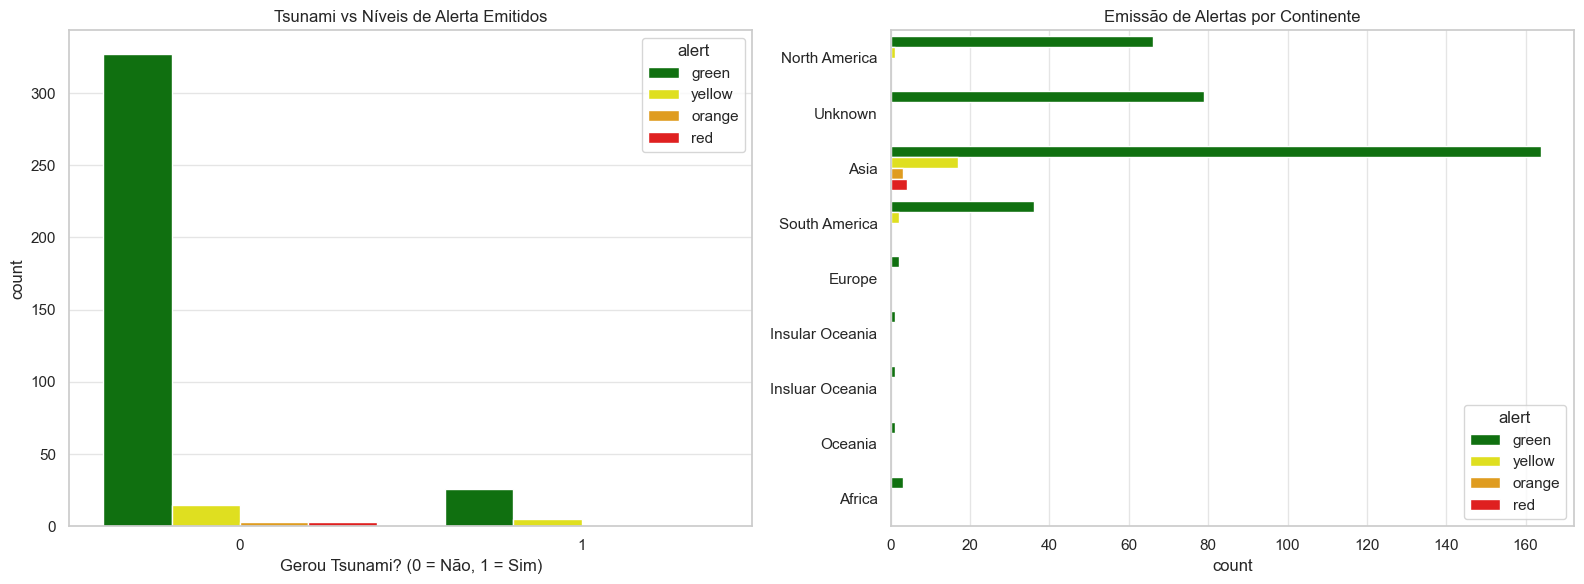

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tsunami vs Alerta (Proporção)
# Removendo No_Alert para ver melhor a proporção nos alertas reais
df_alertas_reais = df[df['alert'] != 'No_Alert']

sns.countplot(data=df_alertas_reais, x='tsunami', hue='alert',
              hue_order=['green', 'yellow', 'orange', 'red'],
              palette=['green', 'yellow', 'orange', 'red'], ax=axes[0])
axes[0].set_title('Tsunami vs Níveis de Alerta Emitidos')
axes[0].set_xlabel('Gerou Tsunami? (0 = Não, 1 = Sim)')

# Continente vs Alerta
sns.countplot(data=df_alertas_reais, y='continent', hue='alert',
              hue_order=['green', 'yellow', 'orange', 'red'],
              palette=['green', 'yellow', 'orange', 'red'], ax=axes[1])
axes[1].set_title('Emissão de Alertas por Continente')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

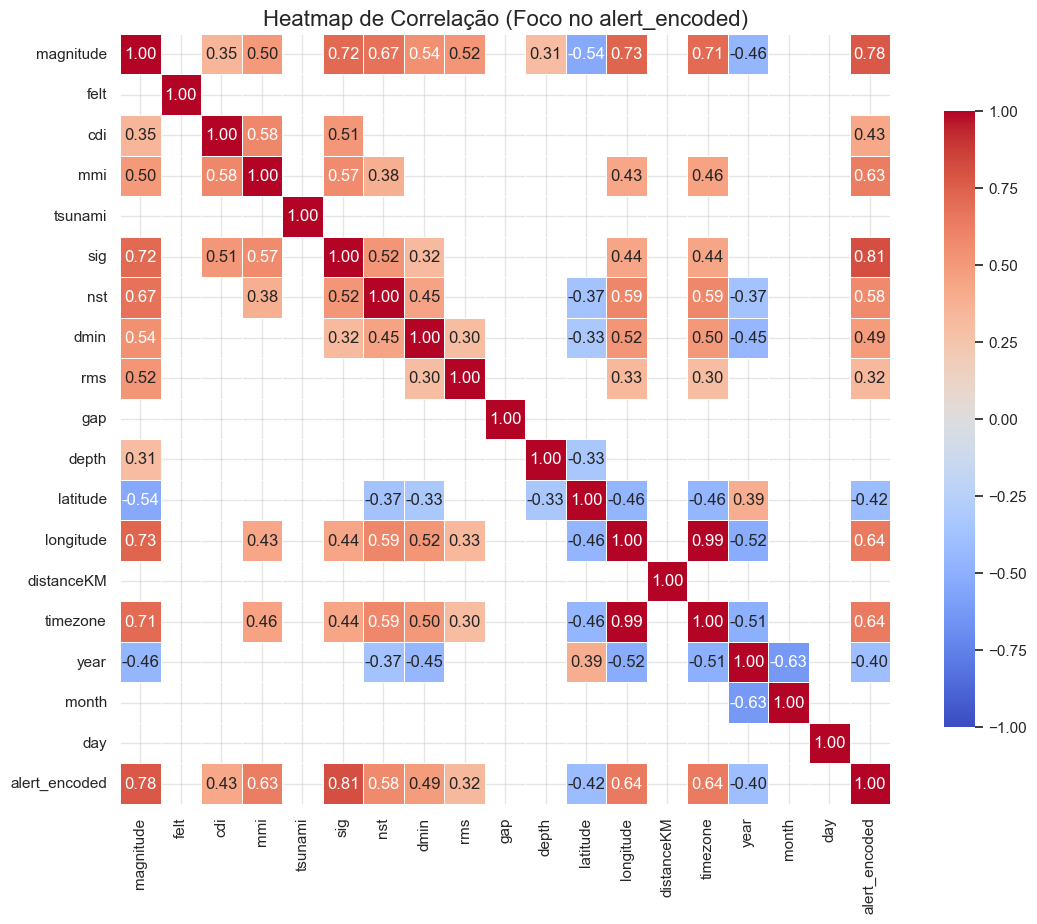

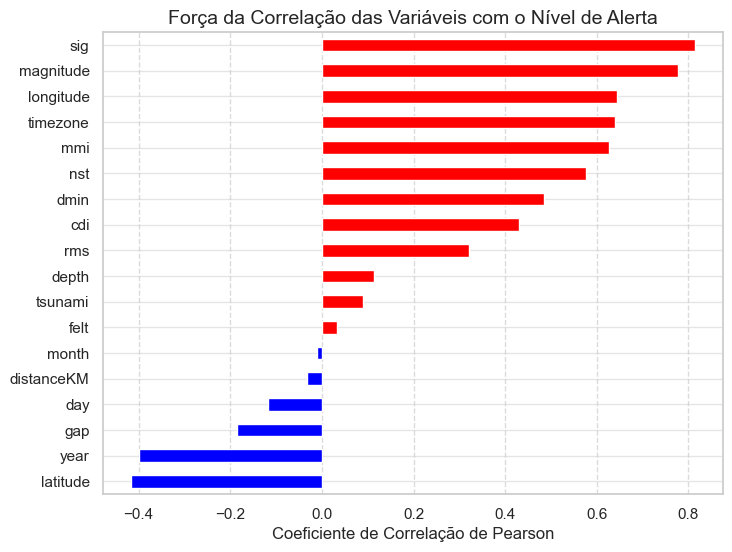

In [10]:
# Pegar apenas colunas numéricas (incluindo o nosso alert_encoded recém-criado)
df_num = df.select_dtypes(include=[np.number])

# Calcular a correlação
corr_matrix = df_num.corr()

# Definir a máscara para esconder correlações fracas (entre -0.3 e 0.3, por exemplo)
threshold = 0.3
mask = abs(corr_matrix) < threshold

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Heatmap de Correlação (Foco no alert_encoded)', fontsize=16)
plt.show()

# Extra: Um gráfico de barras mostrando apenas a correlação direta com o Alvo
plt.figure(figsize=(8, 6))
correlacoes_alvo = corr_matrix['alert_encoded'].drop('alert_encoded').sort_values()
correlacoes_alvo.plot(kind='barh', color=np.where(correlacoes_alvo < 0, 'blue', 'red'))
plt.title('Força da Correlação das Variáveis com o Nível de Alerta', fontsize=14)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()